<a href="https://colab.research.google.com/github/VinceGarcia11/Student-Mental-Health/blob/main/Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

#reading the data
SH_raw = pd.read_csv(r"/content/student_mental_health_burnout.csv")



**bold text**

In [6]:
y = SH_raw['burnout_level'] #target variable
X = pd.get_dummies(SH_raw.drop(['burnout_level','student_id'], axis=1), drop_first=True) #Assisted by Gemini, AI. Here, I used get_dummies for EVERYTHING but the target variable.
#Student ID doesn't need to be here
#Tried to make dummies for y, Gemini suggested against it. Citing that ravel() would not have worked since it has 2 columns.

                         student_id       age  daily_study_hours  \
student_id                 1.000000 -0.003063          -0.000411   
age                       -0.003063  1.000000          -0.000623   
daily_study_hours         -0.000411 -0.000623           1.000000   
daily_sleep_hours          0.000866  0.003084          -0.002353   
screen_time_hours          0.000382 -0.001495           0.001779   
anxiety_score              0.003988  0.001606           0.002771   
depression_score          -0.003620 -0.001968          -0.001497   
academic_pressure_score    0.000461  0.000551          -0.003118   
financial_stress_score     0.001044 -0.001328           0.001919   
social_support_score       0.002099 -0.000104          -0.003394   
physical_activity_hours   -0.002061 -0.003325           0.001722   
attendance_percentage      0.000568 -0.002459          -0.000155   
cgpa                      -0.002804 -0.003290          -0.005450   
gender_Male                0.001817  0.001069   

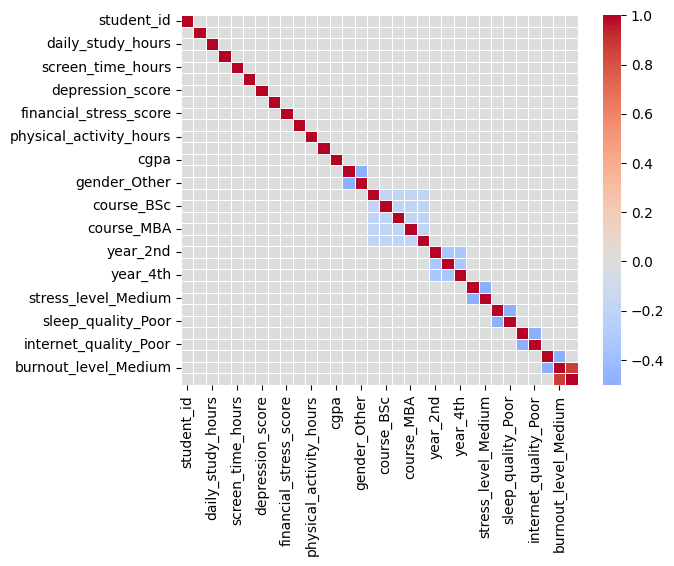

In [7]:
#correlation analysis
x_corr = pd.get_dummies(SH_raw, drop_first=True)
x_corr['burnout_level'] = y.astype('category').cat.codes #sugguested by Gemini AI, needed to make this numeric

pearson_corr = x_corr.corr(method='pearson') #source: https://www.geeksforgeeks.org/data-analysis/exploring-correlation-in-python/
print(pearson_corr) #source: https://www.geeksforgeeks.org/data-analysis/exploring-correlation-in-python/

#Plotting the heatmap, sugguested by Gemini AI
sns.heatmap(
    pearson_corr,
    cmap='coolwarm',     # Red for positive, Blue for negative
    center=0,            # 0 is the neutral color
    linewidths=0.5
)
plt.figure(figsize=(100, 100))
plt.title("Pearson Correlation Heatmap")
plt.show()

In [8]:
#Create a random 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% test, 80% train
    stratify = y,
    random_state=42   # Sets a seed so the random split is reproducible

) #generated by Gemini AI, using test_size and random state made this more varied and reproducible.
#ESPECIALLY since this dataset is synthetic.


In [9]:
import statsmodels.tools.tools as stattools
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
#first model
rf01 = RandomForestClassifier(n_estimators = 100, min_samples_leaf = 30, max_depth = 50).fit(X_train, y_train)
#Make sure I'm outputting an array of high, medium, or low
predict = rf01.predict(X_test)

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
Test_Matrix_01 = confusion_matrix(y_test, predict)

In [11]:
print("Test Matrix")
print(Test_Matrix_01)

Test Matrix
[[3046 3734 3173]
 [3014 3831 3208]
 [3056 3734 3204]]


In [12]:
print(f"Training Accuracy: {rf01.score(X_train, y_train):.2f}") #generated by Gemini to check accuracy

Training Accuracy: 0.86


In [13]:
cart01 = DecisionTreeClassifier(criterion = "gini", max_leaf_nodes=30).fit(X_train, y_train)

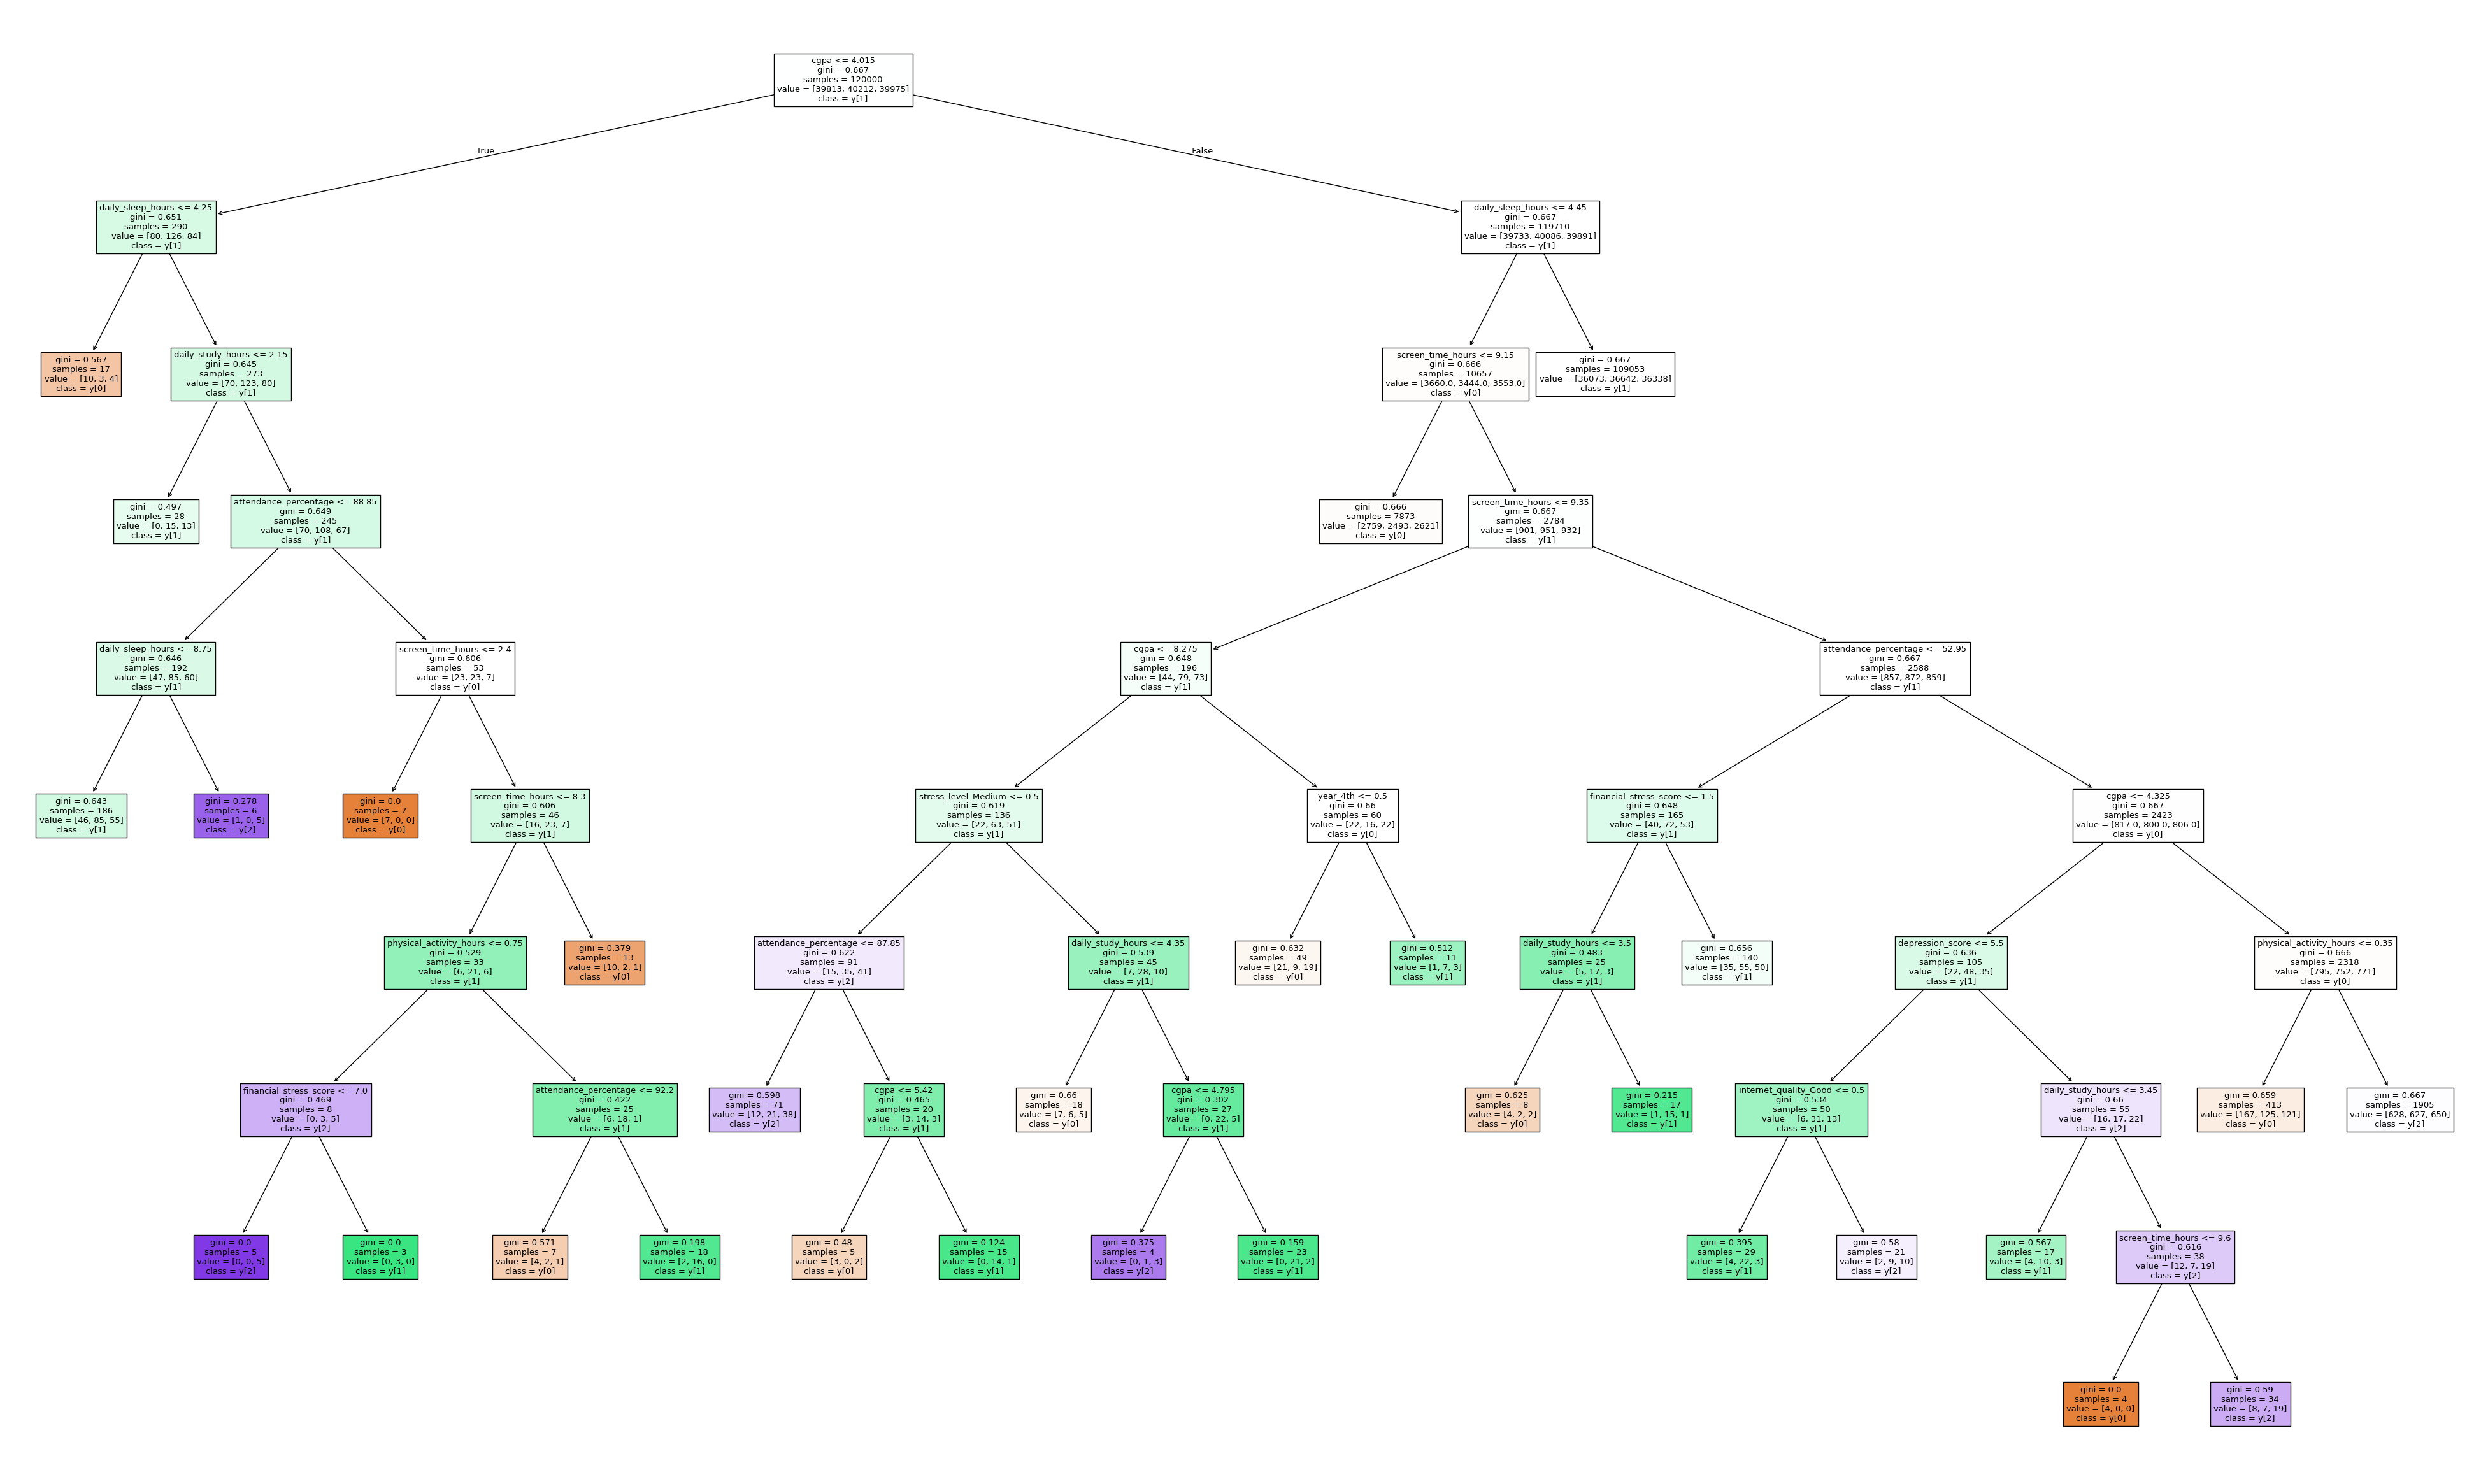

In [14]:
import matplotlib.pyplot as plt
from sklearn import tree

y_names = ["Low", "Medium", "High"]

# Custom Node Color Function
def node_color_function(value):
    if value == 'Low':
        return "lightblue"
    elif value == "High" :
        return "lightred"
    else:
        return "lightgreen"

# Custom color function applied to nodes
fig, ax = plt.subplots(figsize=(50,30))
tree.plot_tree(cart01,
               feature_names=X_train.columns,
               class_names=True,
               filled=True,
               ax=ax)  # plot_tree doesn't directly support custom node functions, so this step remains simple
plt.show()
#source:
#https://www.geeksforgeeks.org/machine-learning/changing-colors-for-decision-tree-plot-using-sklearn-plot-tree/